In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
processed_path = "../data/laptop_processed.csv"

df = pd.read_csv(processed_path)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (1275, 28)

Columns:
['Company', 'Product', 'TypeName', 'Inches', 'ScreenResolution', 'CPU_Company', 'CPU_Type', 'CPU_Frequency (GHz)', 'RAM (GB)', 'Memory', 'GPU_Company', 'GPU_Type', 'OpSys', 'Weight (kg)', 'Price (Euro)', 'SSD_GB', 'HDD_GB', 'Flash_GB', 'Hybrid_GB', 'Total_Storage_GB', 'Storage_Type', 'Resolution_Width', 'Resolution_Height', 'Touchscreen', 'IPS', 'CPU_Family', 'GPU_Family', 'OS_Family']


In [4]:
import joblib
import pandas as pd

# Load final tuned model
model = joblib.load("../models/final_laptop_price_model.pkl")

# Load preprocessor
preprocessor = joblib.load("../models/preprocessor.pkl")

print("Model:", type(model))
print("Preprocessor:", type(preprocessor))

Model: <class 'sklearn.ensemble._forest.RandomForestRegressor'>
Preprocessor: <class 'sklearn.compose._column_transformer.ColumnTransformer'>


In [5]:
feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))

print("\nFirst 20 features:")
for i, feature in enumerate(feature_names[:20]):
    print(i, ":", feature)

Number of processed features: 80

First 20 features:
0 : num__Inches
1 : num__CPU_Frequency (GHz)
2 : num__RAM (GB)
3 : num__Weight (kg)
4 : num__SSD_GB
5 : num__HDD_GB
6 : num__Flash_GB
7 : num__Hybrid_GB
8 : num__Total_Storage_GB
9 : num__Resolution_Width
10 : num__Resolution_Height
11 : num__Touchscreen
12 : num__IPS
13 : cat__Company_Acer
14 : cat__Company_Apple
15 : cat__Company_Asus
16 : cat__Company_Chuwi
17 : cat__Company_Dell
18 : cat__Company_Fujitsu
19 : cat__Company_Google


In [6]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("Top 15 Important Features:")
print(feature_importance.head(15))

Top 15 Important Features:
                      Feature  Importance
0               num__RAM (GB)    0.518256
1            num__Weight (kg)    0.094653
2      cat__TypeName_Notebook    0.061715
3    num__CPU_Frequency (GHz)    0.043054
4     cat__CPU_Family_Core i7    0.040784
5                 num__SSD_GB    0.025440
6                 num__Inches    0.022833
7       num__Resolution_Width    0.021664
8     cat__CPU_Family_Core i5    0.018681
9       num__Total_Storage_GB    0.013970
10  cat__TypeName_Workstation    0.013831
11     num__Resolution_Height    0.013750
12         cat__Company_Razer    0.010927
13       cat__CPU_Family_Xeon    0.010347
14      cat__GPU_Family_Other    0.010097


In [7]:
top10 = feature_importance.head(10)

print("\nTop 10 Features Affecting Laptop Price:")
print(top10)


Top 10 Features Affecting Laptop Price:
                    Feature  Importance
0             num__RAM (GB)    0.518256
1          num__Weight (kg)    0.094653
2    cat__TypeName_Notebook    0.061715
3  num__CPU_Frequency (GHz)    0.043054
4   cat__CPU_Family_Core i7    0.040784
5               num__SSD_GB    0.025440
6               num__Inches    0.022833
7     num__Resolution_Width    0.021664
8   cat__CPU_Family_Core i5    0.018681
9     num__Total_Storage_GB    0.013970


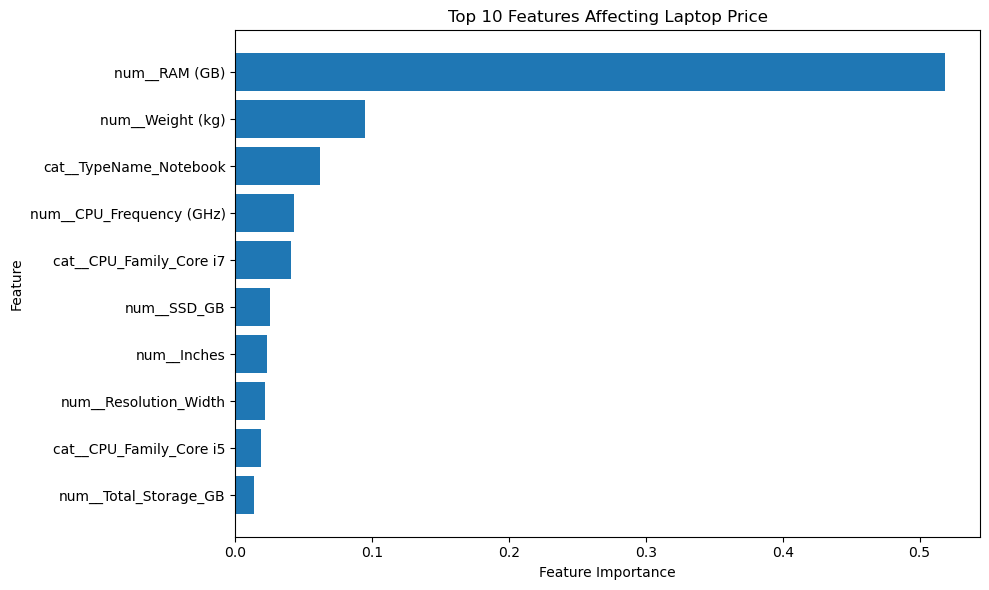

In [8]:
import matplotlib.pyplot as plt

top10 = feature_importance.head(10).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features Affecting Laptop Price")

plt.tight_layout()
plt.show()

In [9]:
feature_importance.to_csv(
    "../data/day9_feature_importance.csv",
    index=False
)

In [10]:
top10_display = feature_importance.head(10).copy()

top10_display

,Feature,Importance
0,num__RAM (GB),0.518256
1,num__Weight (kg),0.094653
2,cat__TypeName_Notebook,0.061715
3,num__CPU_Frequency (GHz),0.043054
4,cat__CPU_Family_Core i7,0.040784
5,num__SSD_GB,0.025440
6,num__Inches,0.022833
7,num__Resolution_Width,0.021664
8,cat__CPU_Family_Core i5,0.018681
9,num__Total_Storage_GB,0.013970


## Model Interpretation

The feature importance analysis shows which features the Random Forest model relied on most when predicting laptop prices.

### Key Findings

- **RAM (GB)** is the most important feature, with an importance of approximately **0.5183**.
- **Weight (kg)** is the second most important feature, with an importance of approximately **0.0947**.
- **Laptop Type (Notebook)** has an importance of approximately **0.0617**.
- **CPU Frequency** contributes approximately **0.0431**.
- **Core i7** has an importance of approximately **0.0408**.
- **SSD storage** contributes approximately **0.0254**.
- Screen size, resolution width, Core i5, and total storage also contribute to the prediction.

### Conclusion

RAM has a significantly higher feature importance than the other features in the trained Random Forest model. This indicates that the model relies heavily on RAM when distinguishing between different laptop price levels.

However, feature importance represents the model's reliance on a feature during tree splitting. It should not be interpreted as direct causation or as saying that RAM alone determines laptop price.

Overall, the model considers a combination of hardware specifications, laptop type, processor characteristics, storage, and display features when predicting laptop prices.